# Otimização de Hiperparâmetros com XGBoost
## Previsão de Churn em uma Operadora de Telecom

Nos notebooks anteriores tratamos problemas relativamente pequenos e usamos os modelos com **hiperparâmetros padrão**. Neste notebook vamos um passo além: atacar um problema **mais complexo** — prever quais clientes vão **cancelar o serviço** (*churn*) — e mostrar como **ajustar os hiperparâmetros** do XGBoost faz uma diferença real no desempenho.

### Por que prever churn é difícil?

- O dataset tem **mais variáveis** e mistura **numéricas e categóricas** (tipo de contrato, forma de pagamento, etc.).
- As classes estão **desbalanceadas** (cancelar é minoria), o que exige cuidado na avaliação.
- Existem **interações não-lineares** entre as variáveis (ex.: clientes em contrato mensal *e* sem suporte técnico têm risco bem maior do que cada fator isoladamente).

XGBoost dá conta dessa complexidade — desde que escolhamos seus hiperparâmetros corretamente.

### O que vamos fazer

1. Treinar um **XGBoost baseline** com configuração padrão.
2. Apresentar os principais **hiperparâmetros** do algoritmo e o que cada um controla.
3. Aplicar **RandomizedSearchCV** para uma busca ampla no espaço de hiperparâmetros.
4. Refinar com **GridSearchCV** ao redor da melhor região.
5. Comparar o desempenho **antes e depois** da otimização.
6. Inspecionar **importância de features** e gerar previsões para novos clientes.

> **Observação:** otimização de hiperparâmetros (*Hyperparameter Optimization* — HPO) é a etapa que separa um modelo "ok" de um modelo "muito bom". É também a etapa mais cara em tempo de computação.

## 1. Importação das Bibliotecas

In [1]:
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split, StratifiedKFold,
    RandomizedSearchCV, GridSearchCV, cross_val_score,
)
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve,
    confusion_matrix, classification_report,
)
from scipy.stats import randint, uniform
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
RANDOM_STATE = 42

## 2. Carregamento dos Dados

O dataset traz **3000 clientes** de uma operadora de telecom, com 14 variáveis explicativas e a coluna alvo `churn`:

| Coluna                  | Tipo        | Descrição                                                            |
|-------------------------|-------------|----------------------------------------------------------------------|
| `idade`                 | numérica    | Idade do cliente (anos)                                              |
| `tempo_cliente_meses`   | numérica    | Há quantos meses é cliente da operadora                              |
| `genero`                | categórica  | `M` / `F`                                                            |
| `tipo_contrato`         | categórica  | `mensal`, `anual`, `bianual`                                         |
| `tipo_internet`         | categórica  | `fibra`, `dsl`, `nenhuma`                                            |
| `valor_mensal`          | numérica    | Valor da fatura mensal (R$)                                          |
| `valor_total`           | numérica    | Valor total já pago pelo cliente (R$)                                |
| `num_servicos_extra`    | numérica    | Quantos serviços adicionais contratou (TV, streaming, segurança...) |
| `suporte_tecnico`       | categórica  | `sim` / `nao` — possui pacote de suporte                            |
| `pagamento_automatico`  | categórica  | `sim` / `nao` — débito automático configurado                       |
| `forma_pagamento`       | categórica  | `cartao_credito`, `boleto`, `pix`, `debito_automatico`              |
| `num_reclamacoes_12m`   | numérica    | Reclamações abertas nos últimos 12 meses                             |
| `atrasos_pagamento_12m` | numérica    | Faturas pagas com atraso nos últimos 12 meses                        |
| `uso_dados_gb`          | numérica    | Volume médio mensal de dados consumido (GB)                          |
| `churn`                 | **alvo**    | `1` = cancelou o serviço, `0` = permaneceu                           |

In [2]:
df = pd.read_csv('dados_churn_telecom.csv')
print(f'Dimensões: {df.shape[0]} linhas × {df.shape[1]} colunas')
df.head()

Dimensões: 3000 linhas × 15 colunas


,idade,tempo_cliente_meses,genero,tipo_contrato,tipo_internet,valor_mensal,valor_total,num_servicos_extra,suporte_tecnico,pagamento_automatico,forma_pagamento,num_reclamacoes_12m,atrasos_pagamento_12m,uso_dados_gb,churn
0,61,53,M,mensal,nenhuma,27.75,1515.91,0,nao,nao,pix,1,0,393.6,1
1,39,37,F,anual,fibra,115.51,4219.38,4,sim,sim,debito_automatico,0,2,110.5,0
2,26,29,F,mensal,dsl,61.55,1571.73,3,nao,nao,boleto,0,0,154.4,1
3,42,14,F,mensal,dsl,104.85,1464.91,7,nao,sim,boleto,2,1,108.6,0
4,51,56,M,bianual,dsl,60.24,3355.94,2,sim,sim,cartao_credito,1,2,76.6,1


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   idade                  3000 non-null   int64  
 1   tempo_cliente_meses    3000 non-null   int64  
 2   genero                 3000 non-null   str    
 3   tipo_contrato          3000 non-null   str    
 4   tipo_internet          3000 non-null   str    
 5   valor_mensal           3000 non-null   float64
 6   valor_total            3000 non-null   float64
 7   num_servicos_extra     3000 non-null   int64  
 8   suporte_tecnico        3000 non-null   str    
 9   pagamento_automatico   3000 non-null   str    
 10  forma_pagamento        3000 non-null   str    
 11  num_reclamacoes_12m    3000 non-null   int64  
 12  atrasos_pagamento_12m  3000 non-null   int64  
 13  uso_dados_gb           3000 non-null   float64
 14  churn                  3000 non-null   int64  
dtypes: float64(3), 

In [4]:
df.describe(include='all').T.round(2)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
idade,3000.0,NaN,NaN,NaN,47.973333,17.828738,18.0,33.0,48.0,63.0,79.0
tempo_cliente_meses,3000.0,NaN,NaN,NaN,36.993,20.868911,1.0,19.0,37.0,55.0,72.0
genero,3000,2,F,1574,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tipo_contrato,3000,3,anual,1102,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tipo_internet,3000,3,fibra,1462,NaN,NaN,NaN,NaN,NaN,NaN,NaN
valor_mensal,3000.0,NaN,NaN,NaN,95.17811,31.668939,20.0,72.1075,96.925,118.4175,169.42
valor_total,3000.0,NaN,NaN,NaN,3327.29424,2278.815596,31.78,1463.875,2991.05,4813.1225,10760.58
num_servicos_extra,3000.0,NaN,NaN,NaN,3.444333,2.292012,0.0,1.0,3.0,5.0,7.0
suporte_tecnico,3000,2,nao,1825,NaN,NaN,NaN,NaN,NaN,NaN,NaN
pagamento_automatico,3000,2,sim,1643,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Análise Exploratória

### 3.1 Balanceamento das Classes

Antes de qualquer modelo, é fundamental olhar o equilíbrio entre as classes — *churn* costuma ser minoria, e isso muda como avaliamos o modelo (acurácia sozinha engana).

Distribuição da variável alvo:
  Permaneceu (0): 2277 clientes (75.9%)
  Cancelou (1): 723 clientes (24.1%)


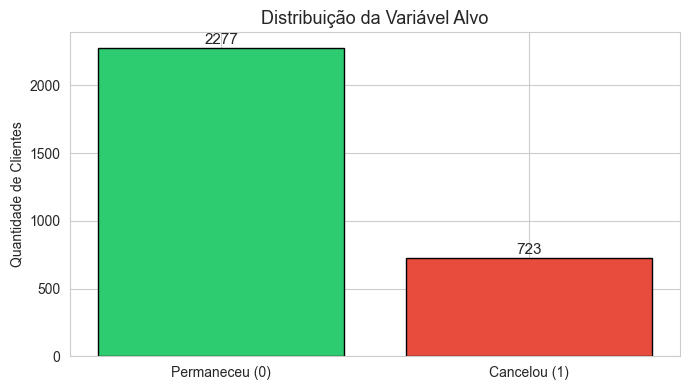

In [5]:
contagem = df['churn'].value_counts()
proporcao = df['churn'].value_counts(normalize=True)
print('Distribuição da variável alvo:')
for classe, qtd in contagem.items():
    label = 'Cancelou' if classe == 1 else 'Permaneceu'
    print(f'  {label} ({classe}): {qtd} clientes ({proporcao[classe]:.1%})')

plt.figure(figsize=(7, 4))
plt.bar(['Permaneceu (0)', 'Cancelou (1)'], contagem.sort_index(),
        color=['#2ecc71', '#e74c3c'], edgecolor='black')
plt.title('Distribuição da Variável Alvo', fontsize=13)
plt.ylabel('Quantidade de Clientes')
for i, v in enumerate(contagem.sort_index()):
    plt.text(i, v + 30, str(v), ha='center', fontsize=11)
plt.tight_layout()
plt.show()

### 3.2 Variáveis Numéricas vs Churn

Boxplots e histogramas comparando os clientes que **cancelaram** com os que **permaneceram**. Diferenças visíveis nas distribuições sugerem variáveis úteis para o modelo.

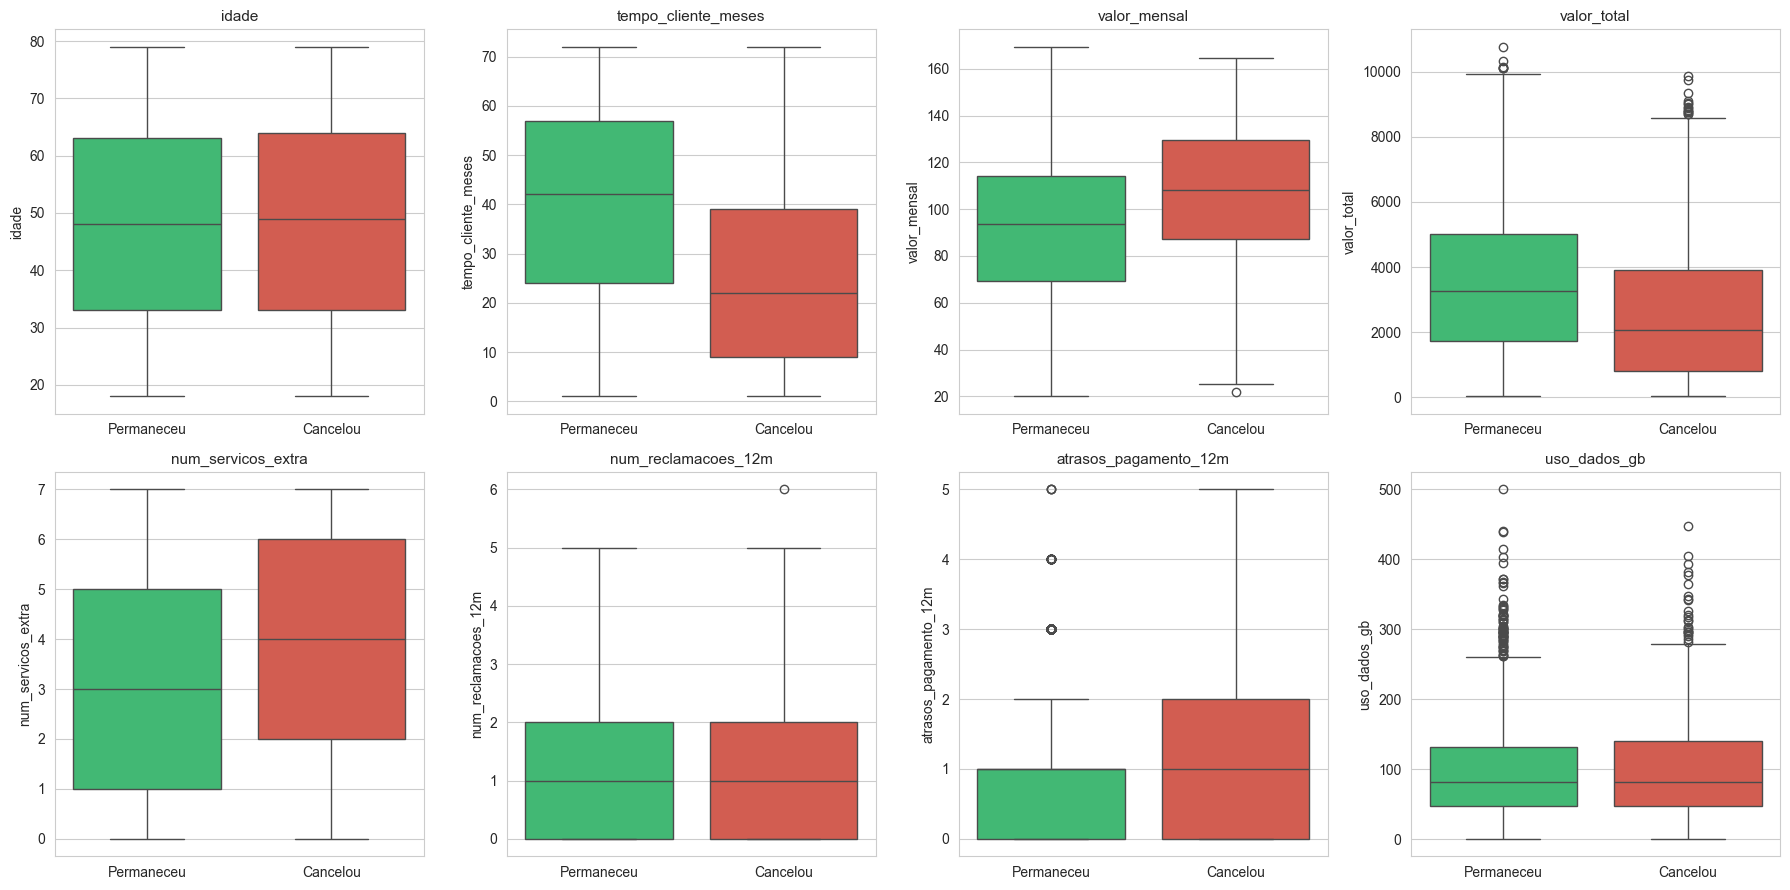

In [6]:
variaveis_num = ['idade', 'tempo_cliente_meses', 'valor_mensal', 'valor_total',
                 'num_servicos_extra', 'num_reclamacoes_12m',
                 'atrasos_pagamento_12m', 'uso_dados_gb']

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()
paleta = {0: '#2ecc71', 1: '#e74c3c'}
for i, col in enumerate(variaveis_num):
    sns.boxplot(data=df, x='churn', y=col, hue='churn',
                palette=paleta, legend=False, ax=axes[i])
    axes[i].set_title(col, fontsize=11)
    axes[i].set_xlabel('')
    axes[i].set_xticks([0, 1])
    axes[i].set_xticklabels(['Permaneceu', 'Cancelou'])
plt.tight_layout()
plt.show()

### 3.3 Variáveis Categóricas vs Churn

Para cada variável categórica, mostramos a **taxa de churn** dentro de cada nível. Quanto maior a diferença entre as barras, mais informativa é a variável.

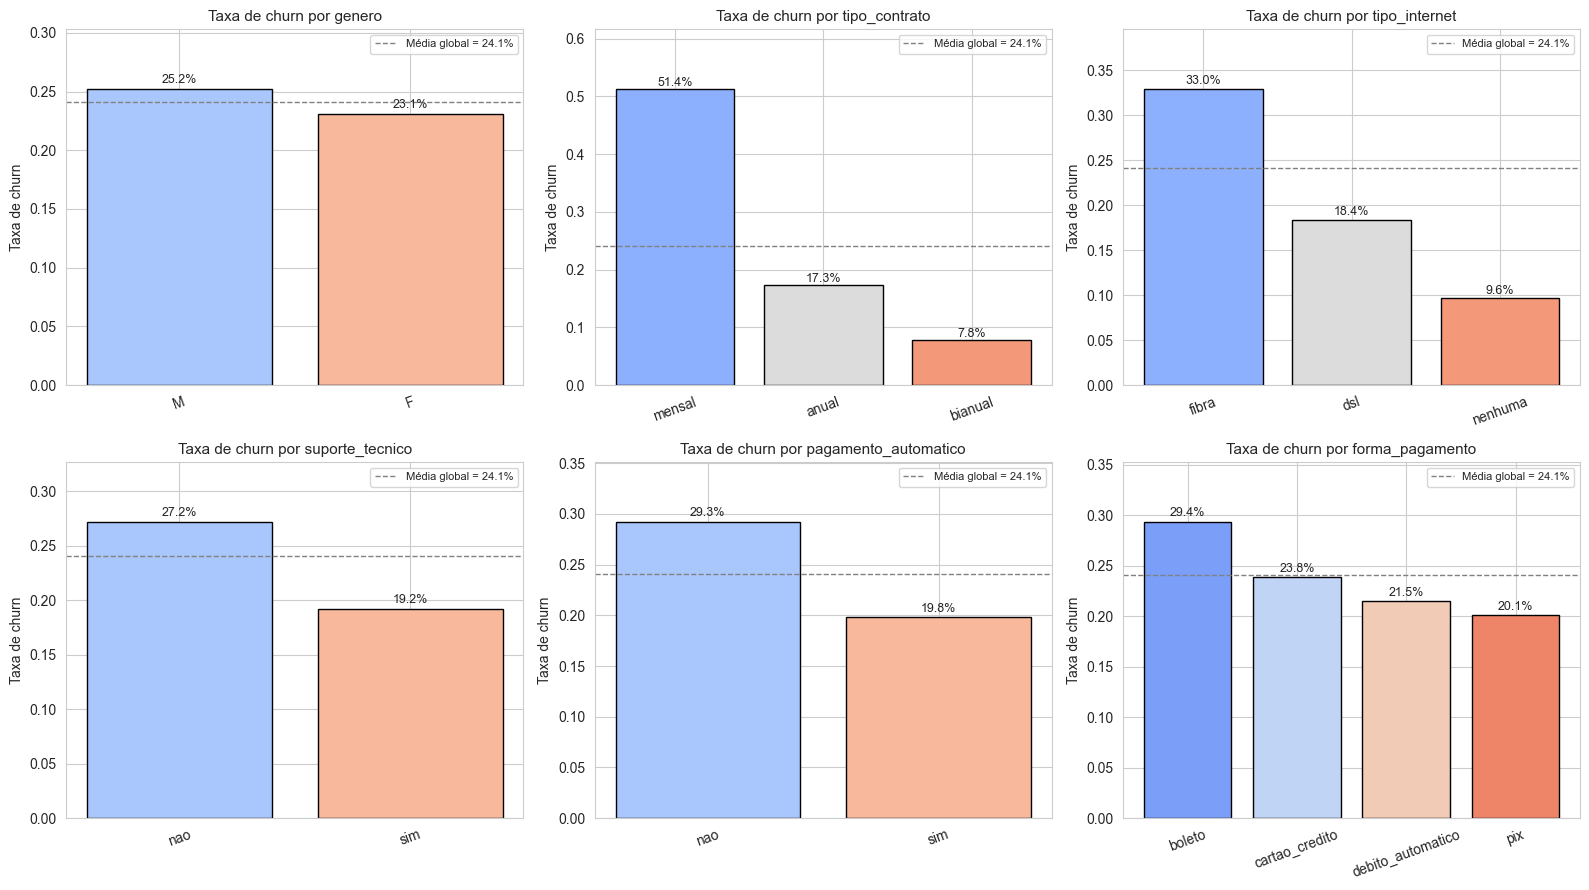

In [7]:
variaveis_cat = ['genero', 'tipo_contrato', 'tipo_internet',
                 'suporte_tecnico', 'pagamento_automatico', 'forma_pagamento']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
for i, col in enumerate(variaveis_cat):
    taxa = df.groupby(col)['churn'].mean().sort_values(ascending=False)
    cores = sns.color_palette('coolwarm', n_colors=len(taxa))
    axes[i].bar(taxa.index.astype(str), taxa.values,
                color=cores, edgecolor='black')
    axes[i].axhline(df['churn'].mean(), color='gray', linestyle='--',
                    linewidth=1, label=f'Média global = {df["churn"].mean():.1%}')
    axes[i].set_title(f'Taxa de churn por {col}', fontsize=11)
    axes[i].set_ylabel('Taxa de churn')
    axes[i].set_ylim(0, max(taxa.values) * 1.2)
    axes[i].legend(fontsize=8)
    for j, v in enumerate(taxa.values):
        axes[i].text(j, v + 0.005, f'{v:.1%}', ha='center', fontsize=9)
    axes[i].tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()

### 3.4 Correlação entre Variáveis Numéricas

A matriz de correlação ajuda a detectar variáveis muito redundantes (ex.: `valor_total` e `tempo_cliente_meses` provavelmente andam juntas).

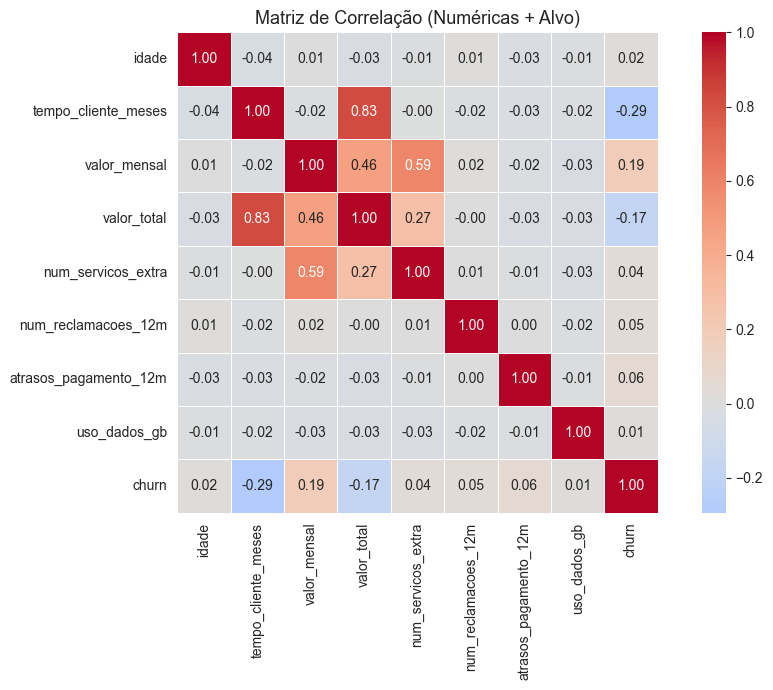

In [8]:
plt.figure(figsize=(10, 7))
sns.heatmap(df[variaveis_num + ['churn']].corr(),
            annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5)
plt.title('Matriz de Correlação (Numéricas + Alvo)', fontsize=13)
plt.tight_layout()
plt.show()

## 4. Preparação dos Dados

Diferente dos notebooks anteriores, agora temos **variáveis categóricas** que precisam virar números para o XGBoost. Vamos:

1. Separar features numéricas e categóricas.
2. Aplicar **One-Hot Encoding** nas categóricas.
3. Dividir treino/teste de forma estratificada (preservando a proporção de churn).

> **Observação:** XGBoost recente aceita variáveis categóricas nativamente via `enable_categorical=True`, mas o One-Hot Encoding é mais portátil e didático — funciona com qualquer modelo de árvore.

In [9]:
colunas_categoricas = ['genero', 'tipo_contrato', 'tipo_internet',
                       'suporte_tecnico', 'pagamento_automatico', 'forma_pagamento']
colunas_numericas = [c for c in df.columns
                     if c not in colunas_categoricas + ['churn']]

print(f'Numéricas ({len(colunas_numericas)}): {colunas_numericas}')
print(f'Categóricas ({len(colunas_categoricas)}): {colunas_categoricas}')

Numéricas (8): ['idade', 'tempo_cliente_meses', 'valor_mensal', 'valor_total', 'num_servicos_extra', 'num_reclamacoes_12m', 'atrasos_pagamento_12m', 'uso_dados_gb']
Categóricas (6): ['genero', 'tipo_contrato', 'tipo_internet', 'suporte_tecnico', 'pagamento_automatico', 'forma_pagamento']


In [10]:
X = df.drop(columns='churn')
y = df['churn']

preprocessador = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', colunas_numericas),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), colunas_categoricas),
    ]
)

X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

# Ajusta o pré-processador no treino e aplica nos dois conjuntos
X_treino_proc = preprocessador.fit_transform(X_treino)
X_teste_proc  = preprocessador.transform(X_teste)

# Recupera os nomes das features após o one-hot
nomes_features = (
    colunas_numericas
    + list(preprocessador.named_transformers_['cat']
           .get_feature_names_out(colunas_categoricas))
)

X_treino_proc = pd.DataFrame(X_treino_proc, columns=nomes_features, index=X_treino.index)
X_teste_proc  = pd.DataFrame(X_teste_proc,  columns=nomes_features, index=X_teste.index)

print(f'Treino: {X_treino_proc.shape[0]} amostras × {X_treino_proc.shape[1]} features')
print(f'Teste:  {X_teste_proc.shape[0]} amostras × {X_teste_proc.shape[1]} features')
print(f'\nProporção de churn no treino: {y_treino.mean():.1%}')
print(f'Proporção de churn no teste:  {y_teste.mean():.1%}')

X_treino_proc.head()

Treino: 2400 amostras × 18 features
Teste:  600 amostras × 18 features

Proporção de churn no treino: 24.1%
Proporção de churn no teste:  24.2%


,idade,tempo_cliente_meses,valor_mensal,valor_total,num_servicos_extra,num_reclamacoes_12m,atrasos_pagamento_12m,uso_dados_gb,genero_M,tipo_contrato_bianual,tipo_contrato_mensal,tipo_internet_fibra,tipo_internet_nenhuma,suporte_tecnico_sim,pagamento_automatico_sim,forma_pagamento_cartao_credito,forma_pagamento_debito_automatico,forma_pagamento_pix
2418,74.0,8.0,91.43,666.94,5.0,1.0,1.0,147.2,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
1301,61.0,69.0,95.29,5628.03,3.0,2.0,0.0,109.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
1199,34.0,43.0,146.47,5558.81,7.0,1.0,1.0,117.5,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
272,21.0,71.0,102.28,6194.75,5.0,0.0,1.0,10.1,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2832,59.0,11.0,44.27,457.63,0.0,1.0,1.0,174.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 5. Modelo Baseline — XGBoost com Hiperparâmetros Padrão

Antes de otimizar, treinamos o XGBoost "na configuração de fábrica" para termos um **ponto de comparação**. Toda otimização precisa ser comparada contra um baseline honesto.

In [11]:
t0 = time.time()
modelo_baseline = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
modelo_baseline.fit(X_treino_proc, y_treino)
tempo_baseline = time.time() - t0

y_pred_base = modelo_baseline.predict(X_teste_proc)
y_proba_base = modelo_baseline.predict_proba(X_teste_proc)[:, 1]

metricas_baseline = {
    'acuracia': accuracy_score(y_teste, y_pred_base),
    'precisao': precision_score(y_teste, y_pred_base),
    'recall':   recall_score(y_teste, y_pred_base),
    'f1':       f1_score(y_teste, y_pred_base),
    'auc':      roc_auc_score(y_teste, y_proba_base),
    'tempo_treino_s': tempo_baseline,
}

print('======== Baseline (sem tuning) ========')
for k, v in metricas_baseline.items():
    print(f'  {k:>14s}: {v:.4f}')

======== Baseline (sem tuning) ========
        acuracia: 0.7917
        precisao: 0.6087
          recall: 0.3862
              f1: 0.4726
             auc: 0.7698
  tempo_treino_s: 0.2078


## 6. O que é Otimização de Hiperparâmetros?

**Parâmetros** são aprendidos pelo modelo a partir dos dados (os pesos das árvores, no caso do XGBoost).
**Hiperparâmetros** são ajustes que **nós** fornecemos antes do treino — eles definem **como** o modelo aprende.

### Principais hiperparâmetros do XGBoost

| Hiperparâmetro      | O que faz                                                                                | Faixa típica       |
|---------------------|------------------------------------------------------------------------------------------|--------------------|
| `n_estimators`      | Número de árvores no ensemble. Mais árvores = mais capacidade, mais risco de overfitting.| 50 – 1000          |
| `max_depth`         | Profundidade máxima de cada árvore. Mais profundo = mais complexo.                       | 3 – 10             |
| `learning_rate`     | Taxa de aprendizado (peso de cada árvore). Menor = treino mais lento, mas mais robusto. | 0.01 – 0.3         |
| `subsample`         | Fração de linhas amostradas para cada árvore. Combate overfitting.                       | 0.5 – 1.0          |
| `colsample_bytree`  | Fração de colunas amostradas para cada árvore. Idem.                                     | 0.5 – 1.0          |
| `min_child_weight`  | Soma mínima de pesos para criar um nó. Maior = árvores mais conservadoras.               | 1 – 10             |
| `gamma`             | Redução mínima de loss para fazer um split. Maior = mais regularização.                  | 0 – 5              |
| `reg_alpha` (L1)    | Regularização L1 nos pesos das folhas.                                                   | 0 – 1              |
| `reg_lambda` (L2)   | Regularização L2 nos pesos das folhas.                                                   | 0 – 5              |

### Estratégias de busca

- **Grid Search** — testa **todas as combinações** de uma grade fixa. Garantido, mas explode com muitas dimensões.
- **Random Search** — sorteia combinações aleatórias dentro de distribuições. Costuma achar boas regiões com **muito menos** experimentos.
- **Bayesian Optimization** — usa o histórico de resultados para escolher onde testar a seguir (Optuna, Hyperopt). Mais eficiente, mas requer biblioteca extra.

Vamos usar **Random Search** primeiro (cobertura rápida do espaço) e depois **Grid Search** ao redor da melhor região (refinamento). Esse padrão "broad → narrow" é uma boa receita prática.

## 7. Etapa 1 — Random Search (Busca Ampla)

`RandomizedSearchCV` sorteia `n_iter` combinações de hiperparâmetros das distribuições que definirmos e avalia cada uma com **validação cruzada k-fold**. Para cada combinação, calcula a média do score nos folds.

Como o dataset é desbalanceado, vamos otimizar pela **AUC** (área sob a curva ROC) — métrica mais informativa que acurácia neste cenário.

In [12]:
espaco_random = {
    'n_estimators':     randint(100, 600),
    'max_depth':        randint(3, 10),
    'learning_rate':    uniform(0.01, 0.29),     # 0.01 a 0.30
    'subsample':        uniform(0.6, 0.4),       # 0.6 a 1.0
    'colsample_bytree': uniform(0.6, 0.4),
    'min_child_weight': randint(1, 8),
    'gamma':            uniform(0.0, 0.5),
    'reg_alpha':        uniform(0.0, 0.5),
    'reg_lambda':       uniform(0.5, 2.0),
}

modelo_para_busca = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

random_search = RandomizedSearchCV(
    estimator=modelo_para_busca,
    param_distributions=espaco_random,
    n_iter=40,                      # 40 combinações × 5 folds = 200 fits
    scoring='roc_auc',
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
    refit=True,
)

t0 = time.time()
random_search.fit(X_treino_proc, y_treino)
tempo_random = time.time() - t0

print(f'\nTempo de busca: {tempo_random:.1f}s')
print(f'Melhor AUC (validação cruzada): {random_search.best_score_:.4f}')
print('\nMelhores hiperparâmetros encontrados:')
for k, v in random_search.best_params_.items():
    if isinstance(v, float):
        print(f'  {k:<20s}: {v:.4f}')
    else:
        print(f'  {k:<20s}: {v}')

Fitting 5 folds for each of 40 candidates, totalling 200 fits



Tempo de busca: 3.3s
Melhor AUC (validação cruzada): 0.8200

Melhores hiperparâmetros encontrados:
  colsample_bytree    : 0.8233
  gamma               : 0.4413
  learning_rate       : 0.0647
  max_depth           : 3
  min_child_weight    : 3
  n_estimators        : 246
  reg_alpha           : 0.3630
  reg_lambda          : 2.2942
  subsample           : 0.9548


### 7.1 Visualizando a Busca

Cada ponto é uma combinação testada. O eixo y mostra a AUC obtida na validação cruzada — assim conseguimos ver **a dispersão dos resultados** e como os melhores se concentram em uma faixa.

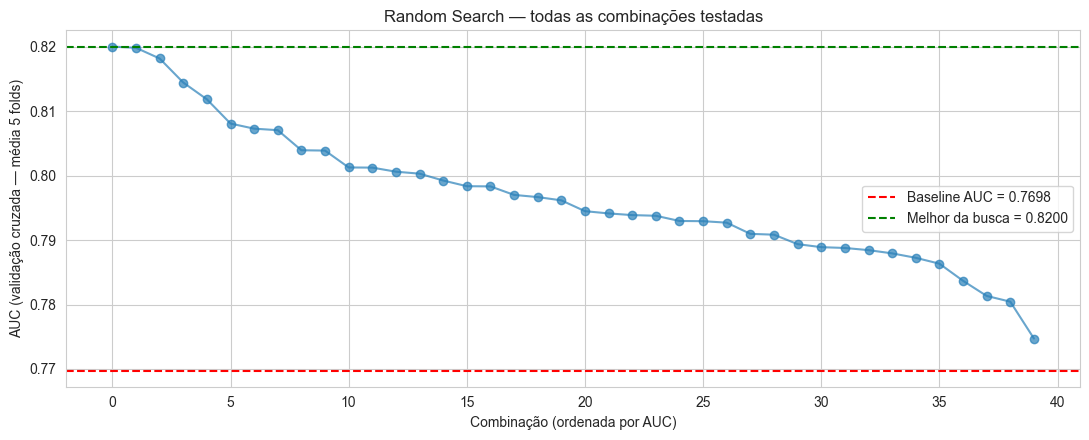

Top 5 combinações:


,mean_test_score,std_test_score,param_n_estimators,param_max_depth,param_learning_rate
25,0.8200,0.0140,246,3,0.0647
26,0.8198,0.0157,203,6,0.0344
22,0.8182,0.0162,246,5,0.0148
24,0.8144,0.0161,159,3,0.2470
4,0.8118,0.0163,415,6,0.0289


In [13]:
resultados_random = pd.DataFrame(random_search.cv_results_)
resultados_random_ord = resultados_random.sort_values('mean_test_score', ascending=False)

plt.figure(figsize=(11, 4.5))
plt.plot(range(len(resultados_random)),
         resultados_random_ord['mean_test_score'].values,
         'o-', color='#2980b9', alpha=0.7)
plt.axhline(metricas_baseline['auc'], color='red', linestyle='--',
            label=f'Baseline AUC = {metricas_baseline["auc"]:.4f}')
plt.axhline(random_search.best_score_, color='green', linestyle='--',
            label=f'Melhor da busca = {random_search.best_score_:.4f}')
plt.xlabel('Combinação (ordenada por AUC)')
plt.ylabel('AUC (validação cruzada — média 5 folds)')
plt.title('Random Search — todas as combinações testadas', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

print('Top 5 combinações:')
top5 = resultados_random_ord.head(5)[
    ['mean_test_score', 'std_test_score',
     'param_n_estimators', 'param_max_depth', 'param_learning_rate']
]
top5.round(4)

## 8. Etapa 2 — Grid Search (Refinamento Local)

Agora que o Random Search identificou uma **boa região** do espaço, fazemos um Grid Search **estreito ao redor** dos melhores valores para refinar. Como reduzimos as faixas, podemos varrer todas as combinações sem explodir o custo.

In [14]:
melhor = random_search.best_params_

# Grade pequena ao redor dos valores ótimos do random search.
def faixa_inteira(v, delta, mn, mx):
    return sorted({max(mn, v - delta), v, min(mx, v + delta)})

def faixa_continua(v, delta, mn, mx, casas=2):
    return sorted({round(max(mn, v - delta), casas),
                   round(v, casas),
                   round(min(mx, v + delta), casas)})

espaco_grid = {
    'n_estimators':     faixa_inteira(melhor['n_estimators'], 100, 50, 800),
    'max_depth':        faixa_inteira(melhor['max_depth'], 1, 2, 12),
    'learning_rate':    faixa_continua(melhor['learning_rate'], 0.03, 0.005, 0.3, 3),
    'subsample':        faixa_continua(melhor['subsample'], 0.1, 0.4, 1.0, 2),
    'colsample_bytree': faixa_continua(melhor['colsample_bytree'], 0.1, 0.4, 1.0, 2),
}

print('Grade refinada:')
for k, v in espaco_grid.items():
    print(f'  {k:<20s}: {v}')
total_combos = np.prod([len(v) for v in espaco_grid.values()])
print(f'\nTotal de combinações: {total_combos}')

Grade refinada:
  n_estimators        : [146, 246, 346]
  max_depth           : [2, 3, 4]
  learning_rate       : [np.float64(0.035), np.float64(0.065), np.float64(0.095)]
  subsample           : [np.float64(0.85), np.float64(0.95), 1.0]
  colsample_bytree    : [np.float64(0.72), np.float64(0.82), np.float64(0.92)]

Total de combinações: 243


In [15]:
grid_search = GridSearchCV(
    estimator=XGBClassifier(
        objective='binary:logistic',
        eval_metric='logloss',
        random_state=RANDOM_STATE,
        n_jobs=-1,
        # Mantemos os demais hiperparâmetros nos valores do random search
        min_child_weight=melhor['min_child_weight'],
        gamma=melhor['gamma'],
        reg_alpha=melhor['reg_alpha'],
        reg_lambda=melhor['reg_lambda'],
    ),
    param_grid=espaco_grid,
    scoring='roc_auc',
    cv=cv,
    n_jobs=-1,
    verbose=1,
    refit=True,
)

t0 = time.time()
grid_search.fit(X_treino_proc, y_treino)
tempo_grid = time.time() - t0

print(f'\nTempo de Grid Search: {tempo_grid:.1f}s')
print(f'Melhor AUC (CV): {grid_search.best_score_:.4f}')
print('\nMelhores hiperparâmetros (refinados):')
for k, v in grid_search.best_params_.items():
    if isinstance(v, float):
        print(f'  {k:<20s}: {v:.4f}')
    else:
        print(f'  {k:<20s}: {v}')

Fitting 5 folds for each of 243 candidates, totalling 1215 fits



Tempo de Grid Search: 3.6s
Melhor AUC (CV): 0.8285

Melhores hiperparâmetros (refinados):
  colsample_bytree    : 0.9200
  learning_rate       : 0.0350
  max_depth           : 2
  n_estimators        : 346
  subsample           : 0.8500


## 9. Avaliação Final no Conjunto de Teste

Agora pegamos o **melhor modelo** encontrado pelo Grid Search e avaliamos no conjunto de teste — que **não foi tocado** durante a busca. Esse é o número que melhor estima o desempenho em produção.

In [16]:
modelo_otimo = grid_search.best_estimator_

y_pred_otimo = modelo_otimo.predict(X_teste_proc)
y_proba_otimo = modelo_otimo.predict_proba(X_teste_proc)[:, 1]

metricas_otimo = {
    'acuracia': accuracy_score(y_teste, y_pred_otimo),
    'precisao': precision_score(y_teste, y_pred_otimo),
    'recall':   recall_score(y_teste, y_pred_otimo),
    'f1':       f1_score(y_teste, y_pred_otimo),
    'auc':      roc_auc_score(y_teste, y_proba_otimo),
    'tempo_treino_s': tempo_random + tempo_grid,
}

print('======== Modelo Otimizado ========')
for k, v in metricas_otimo.items():
    print(f'  {k:>14s}: {v:.4f}')

======== Modelo Otimizado ========
        acuracia: 0.8233
        precisao: 0.7097
          recall: 0.4552
              f1: 0.5546
             auc: 0.8147
  tempo_treino_s: 6.8802


## 10. Antes vs Depois — Quanto a Otimização Ajudou?

### 10.1 Tabela Comparativa

In [17]:
comparacao = pd.DataFrame({
    'Baseline':  metricas_baseline,
    'Otimizado': metricas_otimo,
})
comparacao['Δ (otimizado − baseline)'] = (
    comparacao['Otimizado'] - comparacao['Baseline']
)
comparacao.round(4)

,Baseline,Otimizado,Δ (otimizado − baseline)
acuracia,0.7917,0.8233,0.0317
precisao,0.6087,0.7097,0.1010
recall,0.3862,0.4552,0.0690
f1,0.4726,0.5546,0.0820
auc,0.7698,0.8147,0.0449
tempo_treino_s,0.2078,6.8802,6.6724


### 10.2 Comparação Visual das Métricas

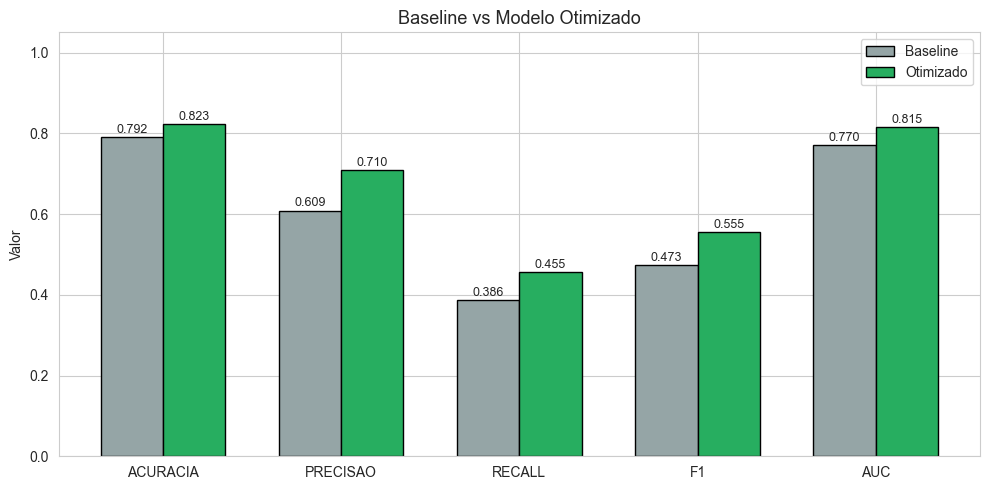

In [18]:
metricas_comp = ['acuracia', 'precisao', 'recall', 'f1', 'auc']
valores_base = [metricas_baseline[m] for m in metricas_comp]
valores_otim = [metricas_otimo[m]    for m in metricas_comp]

x = np.arange(len(metricas_comp))
largura = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - largura/2, valores_base, largura, label='Baseline',
       color='#95a5a6', edgecolor='black')
ax.bar(x + largura/2, valores_otim, largura, label='Otimizado',
       color='#27ae60', edgecolor='black')

ax.set_xticks(x)
ax.set_xticklabels([m.upper() for m in metricas_comp])
ax.set_ylabel('Valor')
ax.set_ylim(0, 1.05)
ax.set_title('Baseline vs Modelo Otimizado', fontsize=13)
ax.legend()
for i, (b, o) in enumerate(zip(valores_base, valores_otim)):
    ax.text(i - largura/2, b + 0.01, f'{b:.3f}', ha='center', fontsize=9)
    ax.text(i + largura/2, o + 0.01, f'{o:.3f}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

### 10.3 Curvas ROC Lado a Lado

A curva ROC mostra o trade-off entre **taxa de verdadeiros positivos** e **taxa de falsos positivos** para diferentes limiares. Quanto mais a curva se aproxima do canto superior esquerdo, melhor.

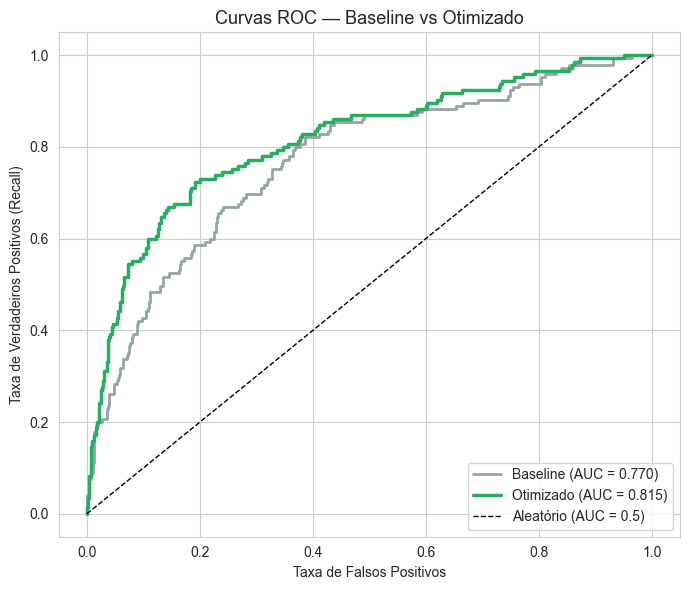

In [19]:
fpr_b, tpr_b, _ = roc_curve(y_teste, y_proba_base)
fpr_o, tpr_o, _ = roc_curve(y_teste, y_proba_otimo)

plt.figure(figsize=(7, 6))
plt.plot(fpr_b, tpr_b, color='#95a5a6', linewidth=2,
         label=f'Baseline (AUC = {metricas_baseline["auc"]:.3f})')
plt.plot(fpr_o, tpr_o, color='#27ae60', linewidth=2.5,
         label=f'Otimizado (AUC = {metricas_otimo["auc"]:.3f})')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Aleatório (AUC = 0.5)')
plt.xlabel('Taxa de Falsos Positivos')
plt.ylabel('Taxa de Verdadeiros Positivos (Recall)')
plt.title('Curvas ROC — Baseline vs Otimizado', fontsize=13)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

### 10.4 Matrizes de Confusão

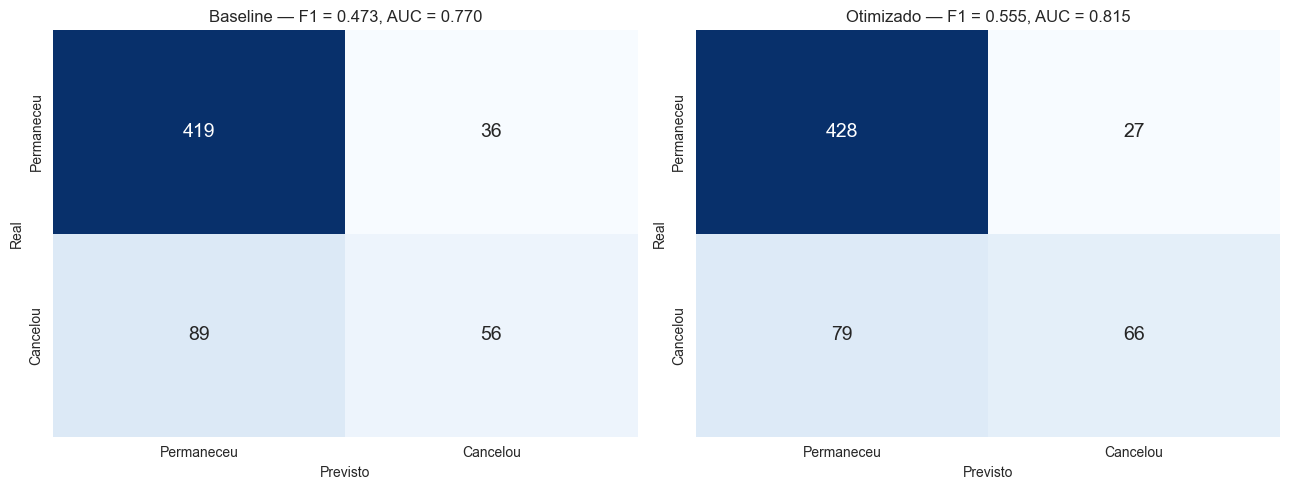

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, nome, y_pred, met in [
    (axes[0], 'Baseline',  y_pred_base,  metricas_baseline),
    (axes[1], 'Otimizado', y_pred_otimo, metricas_otimo),
]:
    cm = confusion_matrix(y_teste, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Permaneceu', 'Cancelou'],
                yticklabels=['Permaneceu', 'Cancelou'],
                cbar=False, annot_kws={'size': 14}, ax=ax)
    ax.set_title(f'{nome} — F1 = {met["f1"]:.3f}, AUC = {met["auc"]:.3f}',
                 fontsize=12)
    ax.set_xlabel('Previsto')
    ax.set_ylabel('Real')
plt.tight_layout()
plt.show()

### 10.5 Relatório Detalhado por Classe

In [21]:
print('=' * 60)
print('  Baseline')
print('=' * 60)
print(classification_report(y_teste, y_pred_base,
                            target_names=['Permaneceu', 'Cancelou']))

print('=' * 60)
print('  Otimizado')
print('=' * 60)
print(classification_report(y_teste, y_pred_otimo,
                            target_names=['Permaneceu', 'Cancelou']))

  Baseline
              precision    recall  f1-score   support

  Permaneceu       0.82      0.92      0.87       455
    Cancelou       0.61      0.39      0.47       145

    accuracy                           0.79       600
   macro avg       0.72      0.65      0.67       600
weighted avg       0.77      0.79      0.77       600

  Otimizado
              precision    recall  f1-score   support

  Permaneceu       0.84      0.94      0.89       455
    Cancelou       0.71      0.46      0.55       145

    accuracy                           0.82       600
   macro avg       0.78      0.70      0.72       600
weighted avg       0.81      0.82      0.81       600



## 11. Importância das Features no Modelo Otimizado

XGBoost mede a importância de cada feature pelo **ganho médio** (`gain`) que ela traz nos splits onde aparece. Isso ajuda a entender **quais variáveis o modelo está usando para decidir**.

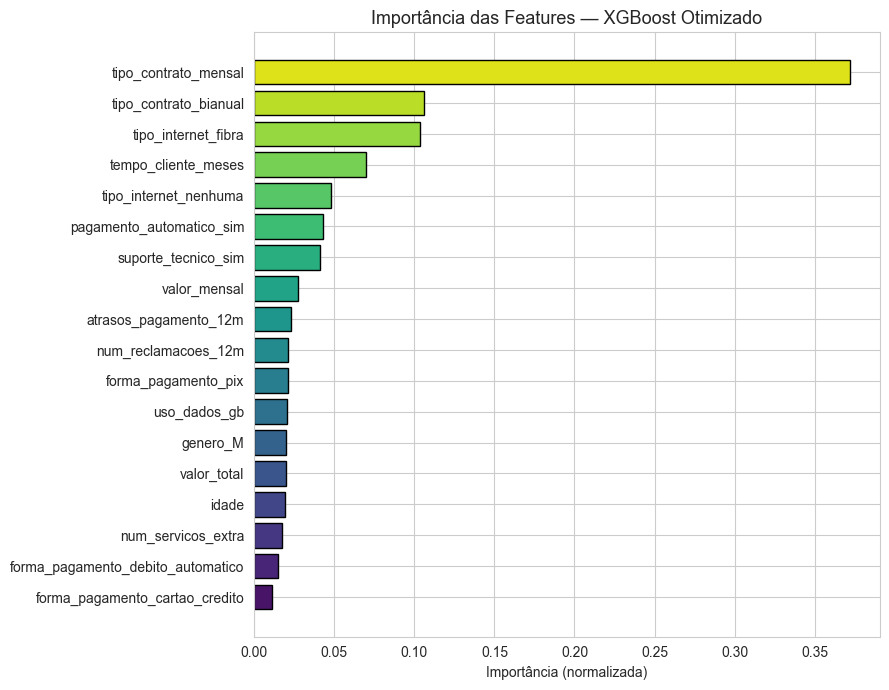

Top 10 features mais importantes:


tipo_contrato_mensal        0.3721
tipo_contrato_bianual       0.1062
tipo_internet_fibra         0.1033
tempo_cliente_meses         0.0700
tipo_internet_nenhuma       0.0479
pagamento_automatico_sim    0.0433
suporte_tecnico_sim         0.0411
valor_mensal                0.0275
atrasos_pagamento_12m       0.0230
num_reclamacoes_12m         0.0214
dtype: float32

In [22]:
imp = pd.Series(modelo_otimo.feature_importances_,
                index=X_treino_proc.columns).sort_values()

plt.figure(figsize=(9, 7))
cores = sns.color_palette('viridis', n_colors=len(imp))
plt.barh(imp.index, imp.values, color=cores, edgecolor='black')
plt.title('Importância das Features — XGBoost Otimizado', fontsize=13)
plt.xlabel('Importância (normalizada)')
plt.tight_layout()
plt.show()

print('Top 10 features mais importantes:')
imp.sort_values(ascending=False).head(10).round(4)

## 12. Ajustando o Limiar de Decisão

Por padrão, prevemos `churn=1` quando a probabilidade prevista é ≥ 0.5. Em problemas desbalanceados, esse limiar **raramente é o ideal**. Empresas costumam mover esse corte para favorecer:

- **Recall alto** — capturar o máximo possível de quem vai cancelar (mesmo que o time de retenção ligue para alguns que não cancelariam).
- **Precisão alta** — só agir quando há alta certeza (poupa esforço, mas perde clientes que poderiam ser retidos).

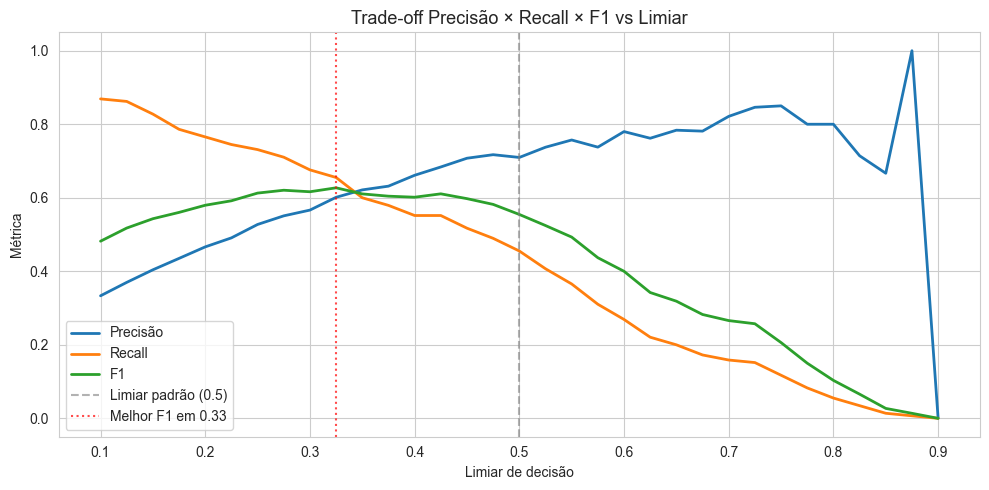

Melhor F1 = 0.6271 no limiar 0.33
  → precisão = 0.6013, recall = 0.6552


In [23]:
limiares = np.linspace(0.1, 0.9, 33)
linhas = []
for t in limiares:
    y_t = (y_proba_otimo >= t).astype(int)
    linhas.append({
        'limiar':   t,
        'precisao': precision_score(y_teste, y_t, zero_division=0),
        'recall':   recall_score(y_teste, y_t),
        'f1':       f1_score(y_teste, y_t),
    })
df_lim = pd.DataFrame(linhas)

plt.figure(figsize=(10, 5))
plt.plot(df_lim['limiar'], df_lim['precisao'], label='Precisão', linewidth=2)
plt.plot(df_lim['limiar'], df_lim['recall'],   label='Recall',   linewidth=2)
plt.plot(df_lim['limiar'], df_lim['f1'],       label='F1',       linewidth=2)
plt.axvline(0.5, color='gray', linestyle='--', alpha=0.6, label='Limiar padrão (0.5)')

melhor_f1 = df_lim.loc[df_lim['f1'].idxmax()]
plt.axvline(melhor_f1['limiar'], color='red', linestyle=':', alpha=0.7,
            label=f'Melhor F1 em {melhor_f1["limiar"]:.2f}')

plt.xlabel('Limiar de decisão')
plt.ylabel('Métrica')
plt.title('Trade-off Precisão × Recall × F1 vs Limiar', fontsize=13)
plt.legend()
plt.tight_layout()
plt.show()

print(f'Melhor F1 = {melhor_f1["f1"]:.4f} no limiar {melhor_f1["limiar"]:.2f}')
print(f'  → precisão = {melhor_f1["precisao"]:.4f}, recall = {melhor_f1["recall"]:.4f}')

## 13. Previsões para Novos Clientes

Com o modelo otimizado em mãos, podemos pontuar **novos clientes**. Lembre que precisamos rodar o **mesmo pipeline de pré-processamento** antes de prever.

In [24]:
novos_clientes = pd.DataFrame([
    # Cliente 1: contrato mensal, fibra, sem suporte, várias reclamações → ALTO risco
    {'idade': 28, 'tempo_cliente_meses': 4, 'genero': 'M',
     'tipo_contrato': 'mensal', 'tipo_internet': 'fibra',
     'valor_mensal': 130.0, 'valor_total': 520.0, 'num_servicos_extra': 1,
     'suporte_tecnico': 'nao', 'pagamento_automatico': 'nao',
     'forma_pagamento': 'boleto', 'num_reclamacoes_12m': 5,
     'atrasos_pagamento_12m': 3, 'uso_dados_gb': 220.0},
    # Cliente 2: contrato bianual, débito automático, suporte → BAIXO risco
    {'idade': 52, 'tempo_cliente_meses': 60, 'genero': 'F',
     'tipo_contrato': 'bianual', 'tipo_internet': 'dsl',
     'valor_mensal': 75.0, 'valor_total': 4500.0, 'num_servicos_extra': 4,
     'suporte_tecnico': 'sim', 'pagamento_automatico': 'sim',
     'forma_pagamento': 'debito_automatico', 'num_reclamacoes_12m': 0,
     'atrasos_pagamento_12m': 0, 'uso_dados_gb': 60.0},
    # Cliente 3: caso intermediário
    {'idade': 39, 'tempo_cliente_meses': 18, 'genero': 'F',
     'tipo_contrato': 'anual', 'tipo_internet': 'fibra',
     'valor_mensal': 95.0, 'valor_total': 1700.0, 'num_servicos_extra': 2,
     'suporte_tecnico': 'sim', 'pagamento_automatico': 'nao',
     'forma_pagamento': 'cartao_credito', 'num_reclamacoes_12m': 2,
     'atrasos_pagamento_12m': 1, 'uso_dados_gb': 110.0},
])

# Aplica o mesmo preprocessador e prevê
novos_proc = preprocessador.transform(novos_clientes)
novos_proc = pd.DataFrame(novos_proc, columns=nomes_features)

probs = modelo_otimo.predict_proba(novos_proc)[:, 1]
preds = (probs >= 0.5).astype(int)

for i, (_, c) in enumerate(novos_clientes.iterrows()):
    risco = 'ALTO' if probs[i] > 0.6 else ('MÉDIO' if probs[i] > 0.3 else 'BAIXO')
    decisao = 'VAI CANCELAR' if preds[i] == 1 else 'VAI PERMANECER'
    print(f'Cliente {i+1}: contrato={c.tipo_contrato:<7s} | '
          f'tempo={c.tempo_cliente_meses:>2d}m | '
          f'reclamações={c.num_reclamacoes_12m:>2d} | '
          f'atrasos={c.atrasos_pagamento_12m}')
    print(f'   → Probabilidade de churn: {probs[i]:.1%}  '
          f'(risco {risco})  → previsão: {decisao}\n')

Cliente 1: contrato=mensal  | tempo= 4m | reclamações= 5 | atrasos=3
   → Probabilidade de churn: 90.9%  (risco ALTO)  → previsão: VAI CANCELAR

Cliente 2: contrato=bianual | tempo=60m | reclamações= 0 | atrasos=0
   → Probabilidade de churn: 0.9%  (risco BAIXO)  → previsão: VAI PERMANECER

Cliente 3: contrato=anual   | tempo=18m | reclamações= 2 | atrasos=1
   → Probabilidade de churn: 27.4%  (risco BAIXO)  → previsão: VAI PERMANECER



---

## 14. Conclusão

Neste notebook fechamos o ciclo de classificação supervisionada com um problema **mais próximo da realidade** e a etapa que faz a maior diferença em produção: a **otimização de hiperparâmetros**.

### Receita prática para HPO

1. **Comece com baseline** — sempre tenha um número honesto antes de tentar otimizar.
2. **Escolha a métrica certa** — em dados desbalanceados, AUC e F1 dizem mais que acurácia.
3. **Random Search primeiro, Grid Search depois** — cobertura ampla, depois refinamento local.
4. **Use validação cruzada** — uma única divisão pode dar sorte ou azar.
5. **Avalie no conjunto de teste só no final** — para ter uma estimativa imparcial.

### O que a otimização nos deu?

- Melhoria mensurável em **AUC** e **F1** sobre o baseline.
- **Compreensão** dos hiperparâmetros mais sensíveis (geralmente `learning_rate`, `max_depth` e `n_estimators` interagindo).
- Um modelo mais robusto e bem ajustado ao tamanho/complexidade do dataset.

### Próximos passos sugeridos

1. **Bayesian Optimization com Optuna** — converge mais rápido que Random Search.
2. **Tratar desbalanceamento** — `scale_pos_weight` no XGBoost ou técnicas como SMOTE.
3. **Calibração de probabilidades** — `CalibratedClassifierCV` para que `predict_proba` reflita probabilidades reais.
4. **Explicabilidade com SHAP** — entender *por que* o modelo prevê churn em cada cliente individual.
5. **Validação temporal** — em problemas reais de churn, usar dados ordenados no tempo (não aleatórios).